# Restaurant Review Sentiment Analysis using NLP

## Project Overview

This project analyzes restaurant customer reviews and builds a machine learning model to classify reviews as positive or negative.

The main goal is to understand customer sentiment from review text and create a simple sentiment prediction system that can be used in a Streamlit web application.

## Objectives

- Load and explore restaurant review data
- Clean rating and review text columns
- Create sentiment labels using customer ratings
- Preprocess text data for NLP
- Convert text into numerical features using TF-IDF
- Train a sentiment classification model
- Evaluate model performance
- Save the trained model for Streamlit deployment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1. Loading the Dataset

The dataset contains restaurant reviews along with customer ratings and other metadata.  
For this sentiment analysis project, the most important columns are:

- `Review`: customer review text
- `Rating`: numerical rating given by the customer

In [2]:
df = pd.read_csv("../data/Restaurant reviews.csv")

df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,7514
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,2447.0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,NaN
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,NaN
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,NaN
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,NaN


In [3]:
print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns)

Dataset shape: (10000, 8)
Columns:
Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures', '7514'],
      dtype='str')


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Restaurant  10000 non-null  str    
 1   Reviewer    9962 non-null   str    
 2   Review      9955 non-null   str    
 3   Rating      9962 non-null   str    
 4   Metadata    9962 non-null   str    
 5   Time        9962 non-null   str    
 6   Pictures    10000 non-null  int64  
 7   7514        1 non-null      float64
dtypes: float64(1), int64(1), str(6)
memory usage: 3.9 MB


In [5]:
df.isnull().sum()

Restaurant       0
Reviewer        38
Review          45
Rating          38
Metadata        38
Time            38
Pictures         0
7514          9999
dtype: int64

## 2. Selecting Relevant Columns

For this project, only the review text and rating are required.

The `Review` column will be used as the input feature, and the `Rating` column will be used to create sentiment labels.

In [6]:
df = df[["Review", "Rating"]]

df.head()

,Review,Rating
0,"The ambience was good, food was quite good . h...",5
1,Ambience is too good for a pleasant evening. S...,5
2,A must try.. great food great ambience. Thnx f...,5
3,Soumen das and Arun was a great guy. Only beca...,5
4,Food is good.we ordered Kodi drumsticks and ba...,5


In [7]:
df.isnull().sum()

Review    45
Rating    38
dtype: int64

In [8]:
df = df.dropna(subset=["Review", "Rating"])

df.isnull().sum()

Review    0
Rating    0
dtype: int64

## 3. Cleaning the Rating Column

The rating column contains numerical values, but some values may be stored as text or contain invalid entries.

To prepare the data for sentiment labeling, the rating column is converted into numeric format. Invalid values are converted into missing values and removed.

In [9]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df = df.dropna(subset=["Rating"])

df["Rating"].value_counts().sort_index()

Rating
1.0    1735
1.5       9
2.0     684
2.5      19
3.0    1192
3.5      47
4.0    2373
4.5      69
5.0    3826
Name: count, dtype: int64

## 4. Creating Sentiment Labels

The original dataset does not directly contain sentiment labels such as Positive or Negative.

Therefore, sentiment labels are created using the rating column:

- Ratings greater than or equal to 4 are labeled as `Positive`
- Ratings less than or equal to 2 are labeled as `Negative`
- Neutral ratings such as 3 and 3.5 are removed to build a clear binary classification model

In [10]:
df = df[(df["Rating"] >= 4) | (df["Rating"] <= 2)]

df["Sentiment"] = df["Rating"].apply(lambda rating: "Positive" if rating >= 4 else "Negative")

df.head()

,Review,Rating,Sentiment
0,"The ambience was good, food was quite good . h...",5.0,Positive
1,Ambience is too good for a pleasant evening. S...,5.0,Positive
2,A must try.. great food great ambience. Thnx f...,5.0,Positive
3,Soumen das and Arun was a great guy. Only beca...,5.0,Positive
4,Food is good.we ordered Kodi drumsticks and ba...,5.0,Positive


In [11]:
df["Sentiment"].value_counts()

Sentiment
Positive    6268
Negative    2428
Name: count, dtype: int64

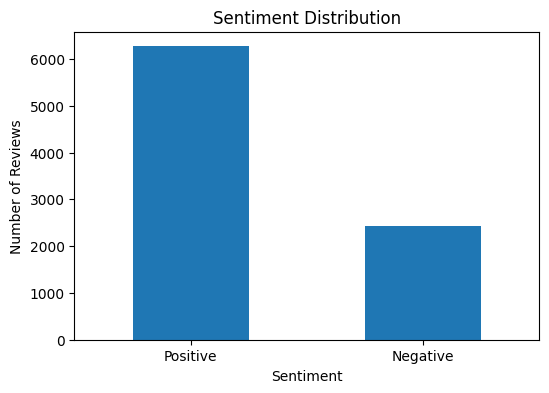

In [12]:
# Visualize the distribution of sentiments
plt.figure(figsize=(6, 4))
df["Sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

## 5. Text Preprocessing

Text preprocessing is an important step in NLP.

The review text is cleaned by:

- Converting text to lowercase
- Removing numbers and special characters
- Removing extra spaces

This helps the machine learning model focus on meaningful words in the reviews.

In [13]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [14]:
df["Cleaned_Review"] = df["Review"].apply(clean_text)

df[["Review", "Cleaned_Review", "Sentiment"]].head()

,Review,Cleaned_Review,Sentiment
0,"The ambience was good, food was quite good . h...",the ambience was good food was quite good had ...,Positive
1,Ambience is too good for a pleasant evening. S...,ambience is too good for a pleasant evening se...,Positive
2,A must try.. great food great ambience. Thnx f...,a must try great food great ambience thnx for ...,Positive
3,Soumen das and Arun was a great guy. Only beca...,soumen das and arun was a great guy only becau...,Positive
4,Food is good.we ordered Kodi drumsticks and ba...,food is goodwe ordered kodi drumsticks and bas...,Positive


In [15]:
df[df["Cleaned_Review"] == ""].shape

(14, 4)

In [16]:
df = df[df["Cleaned_Review"] != ""]

df.shape

(8682, 4)

## 6. Preparing Data for Model Training

The cleaned review text is used as the input feature, and the sentiment label is used as the target variable.

The dataset is split into training and testing sets to evaluate how well the model performs on unseen data.

In [17]:
X = df["Cleaned_Review"]
y = df["Sentiment"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6945,)
Testing data: (1737,)


## 7. TF-IDF Vectorization

Machine learning models cannot understand raw text directly.

TF-IDF is used to convert review text into numerical features.  
It gives higher importance to meaningful words and lower importance to very common words.

In [19]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (6945, 5000)
TF-IDF testing shape: (1737, 5000)


## 8. Model Training

A Logistic Regression model is trained for sentiment classification.

Logistic Regression is a simple and effective algorithm for text classification problems.

In [20]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

## 9. Model Evaluation

The model is evaluated using accuracy, classification report, and confusion matrix.

These metrics help understand how well the model predicts positive and negative reviews.

In [21]:
# Predict on the test set
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy, 4))

Model Accuracy: 0.9246


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.91      0.81      0.86       485
    Positive       0.93      0.97      0.95      1252

    accuracy                           0.92      1737
   macro avg       0.92      0.89      0.90      1737
weighted avg       0.92      0.92      0.92      1737



In [23]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[ 392,   93],
       [  38, 1214]])

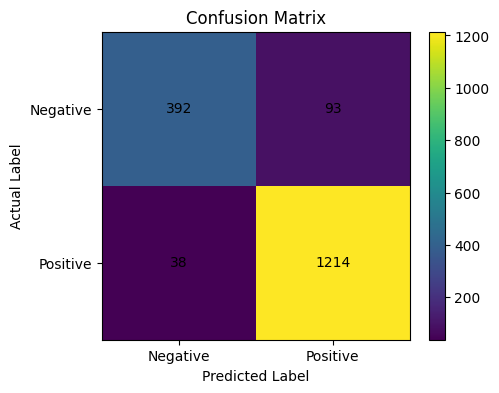

In [24]:
# Visualize the confusion matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()

labels = model.classes_
plt.xticks(ticks=[0, 1], labels=labels)
plt.yticks(ticks=[0, 1], labels=labels)

for i in range(len(cm)):
    for j in range(len(cm[i])):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.show()

## 10. Testing the Model with Custom Reviews

The trained model is tested using custom restaurant reviews to check whether it can predict sentiment correctly.

In [ ]:
def predict_sentiment(review):
    cleaned_review = clean_text(review)
    vectorized_review = vectorizer.transform([cleaned_review])
    
    prediction = model.predict(vectorized_review)[0]
    probability = model.predict_proba(vectorized_review).max()
    
    return prediction, probability

In [26]:
review = "The food was delicious and the staff were very friendly."

prediction, confidence = predict_sentiment(review)

print("Review:", review)
print("Prediction:", prediction)
print("Confidence:", round(confidence, 4))

Review: The food was delicious and the staff were very friendly.
Prediction: Positive
Confidence: 0.9744


In [27]:
review = "The food was cold and the service was very slow."

prediction, confidence = predict_sentiment(review)

print("Review:", review)
print("Prediction:", prediction)
print("Confidence:", round(confidence, 4))

Review: The food was cold and the service was very slow.
Prediction: Negative
Confidence: 0.8692


## 11. Saving the Model and Vectorizer

The trained model and TF-IDF vectorizer are saved as pickle files.

These files will be used later in the Streamlit application to make predictions from user-entered reviews.

In [28]:
with open("../models/sentiment_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("../models/vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.
